In [15]:
import pandas as pd
data = pd.read_csv('imputed_data.csv')
head = data.head()
head

,loan_amnt,verification_status,pub_rec_bankruptcies,tax_liens,tot_hi_cred_lim,total_bal_ex_mort,total_bc_limit,total_il_high_credit_limit,disbursement_method,debt_settlement_flag,...,total_acc,loan_paid,has_imputed_values,monthly_income,payment_to_income_ratio,earliest_cr_line_date,credit_age_years,payment_ratio_to_loan,loan_to_income_ratio,fico_score
0,8000,Source Verified,0.0,0.0,148879.0,41401.0,25300.0,33679.0,Cash,N,...,24.0,1,0,14166.666667,0.018606,2004-12-01,20.281999,0.032947,0.047059,739
1,12750,Verified,0.0,0.0,104074.0,79717.0,0.0,98374.0,Cash,N,...,27.0,1,0,6250.000000,0.067749,2003-11-01,21.366188,0.033210,0.170000,743
2,12000,Source Verified,0.0,0.0,23930.0,16536.0,8800.0,14130.0,Cash,N,...,13.0,0,0,5000.000000,0.083916,2001-10-01,23.449692,0.034965,0.200000,662
3,20000,Verified,0.0,0.0,15800.0,11510.0,8700.0,0.0,Cash,N,...,18.0,1,0,4000.000000,0.133837,1997-08-01,27.616701,0.026767,0.416667,586
4,30000,Not Verified,1.0,0.0,54683.0,26857.0,7500.0,44583.0,Cash,N,...,13.0,0,0,2083.333333,0.471658,1990-03-01,35.036277,0.032754,1.200000,503


In [17]:
# get monthly income

data["monthly_income"] = data.annual_inc/12
data[["monthly_income", "annual_inc"]]


,monthly_income,annual_inc
0,14166.666667,170000.0
1,6250.000000,75000.0
2,5000.000000,60000.0
3,4000.000000,48000.0
4,2083.333333,25000.0
...,...,...
209995,9688.500000,116262.0
209996,16666.666667,200000.0
209997,6378.000000,76536.0
209998,11583.333333,139000.0


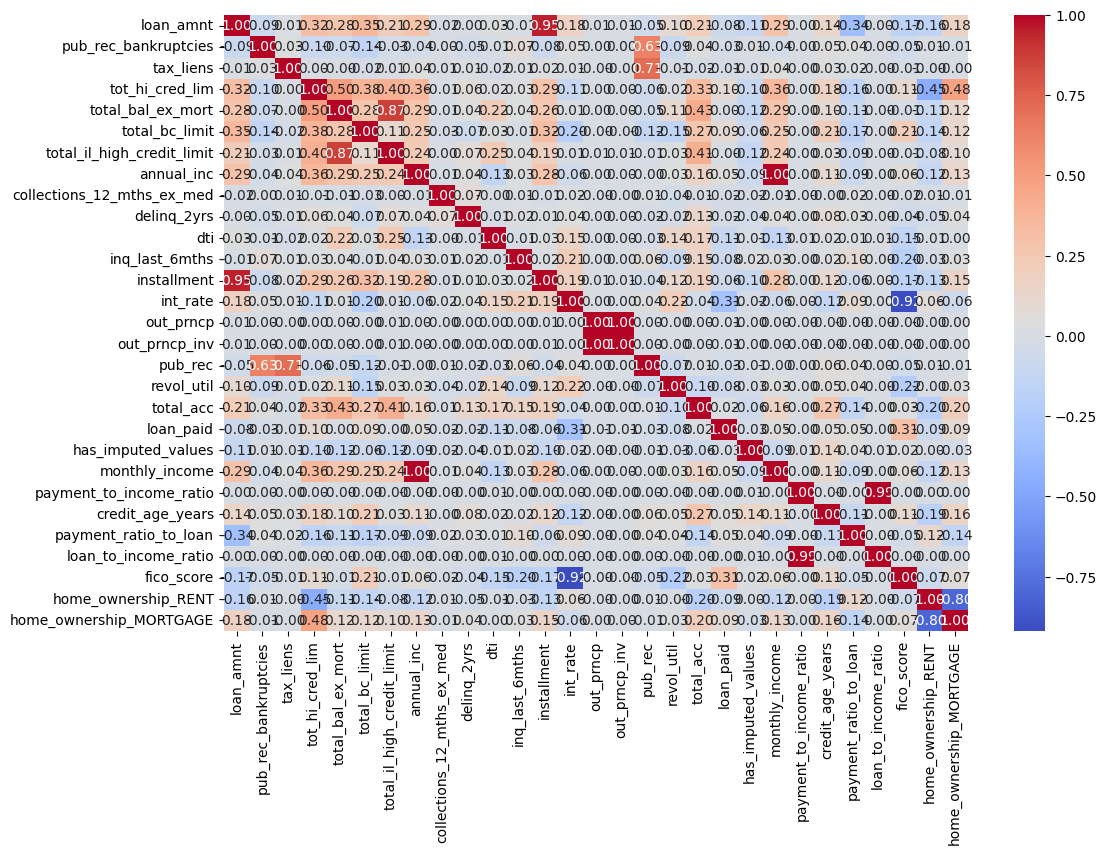

In [42]:
import seaborn as sns
import matplotlib.pyplot as plt
#Multicolinearity Analysis
#Create a correlation matrix of numeric variables 
cor_matrix = data.corr(numeric_only=True)
#print(cor_matrix)

#Display a heatmap of the correlations
plt.figure(figsize=(12,8))
sns.heatmap(cor_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.show()

In [20]:
import pandas as pd
import numpy as np
from datetime import datetime

# Create the four requested features
def create_features(df):
    # 1. Payment to income ratio
    # HAD ISSUE WITH MONTHLY INCOME BEING 0 SO 
# Replace both zeros and NaNs with median value
    median_income = df['monthly_income'].replace(0, np.nan).median()
    df['monthly_income'] = df['monthly_income'].replace(0, median_income)
    
    # Handle annual income
    median_annual_inc = df['annual_inc'].replace(0, np.nan).median()
    df['annual_inc'] = df['annual_inc'].replace(0, median_annual_inc)
    
    
    # 2. Credit age (in years)
    # Convert earliest_cr_line to datetime and calculate age
    df['earliest_cr_line_date'] = pd.to_datetime(df['earliest_cr_line'], format='%b-%Y')
    current_date = datetime.now()
    df['credit_age_years'] = ((current_date - df['earliest_cr_line_date']).dt.days / 365.25)
    
    # 4. Loan amount to income ratio
    df['loan_to_income_ratio'] = df['loan_amnt'] / df['annual_inc']
    
    # Create dummy variables for home ownership
    df['home_ownership_RENT'] = (df['home_ownership'] == 'RENT').astype(int)
    df['home_ownership_MORTGAGE'] = (df['home_ownership'] == 'MORTGAGE').astype(int)
    
    return df

# Apply the function
data = create_features(data)

In [22]:
# Save df to CSV with UTF-8 encoding
data.to_csv('feature_data.csv', index=False, encoding='utf-8')

# Verify the file was created
import os
print(f"File saved to: {os.getcwd()}/feature_data.csv")
print(f"File exists: {os.path.exists('feature_data.csv')}")
print(f"File size: {os.path.getsize('feature_data.csv') / (1024*1024):.2f} MB")

File saved to: c:\CWRU\risk_modeling/feature_data.csv
File exists: True
File size: 58.70 MB


# Apply Process of Feature Selection
- sort feature by business purpose and var type
- univariate analysis (continous var)
- univariate analysis (categorical var)
- IV calc
- Mulitollinearity Check
- VIF calc

In [25]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
# Try to import statsmodels, or install it if missing
try:
    from statsmodels.stats.outliers_influence import variance_inflation_factor
except ImportError:
    print("Installing statsmodels package...")
    import sys
    import subprocess
    subprocess.check_call([sys.executable, "-m", "pip", "install", "statsmodels"])
    from statsmodels.stats.outliers_influence import variance_inflation_factor

Installing statsmodels package...


In [41]:
# Load the data (replace with your actual data path)
df = pd.read_csv('feature_data.csv')

# Check data shape and basic info
print(f"Dataset shape: {df.shape}")
print("\nSample of the data:")
display(df.head())

# Verify target variable
print("\nTarget variable distribution:")
print(df['loan_paid'].value_counts(normalize=True))

Dataset shape: (210000, 40)

Sample of the data:


,loan_amnt,verification_status,pub_rec_bankruptcies,tax_liens,tot_hi_cred_lim,total_bal_ex_mort,total_bc_limit,total_il_high_credit_limit,disbursement_method,debt_settlement_flag,...,has_imputed_values,monthly_income,payment_to_income_ratio,earliest_cr_line_date,credit_age_years,payment_ratio_to_loan,loan_to_income_ratio,fico_score,home_ownership_RENT,home_ownership_MORTGAGE
0,8000,Source Verified,0.0,0.0,148879.0,41401.0,25300.0,33679.0,Cash,N,...,0,14166.666667,0.018606,2004-12-01,20.292950,0.032947,0.047059,739,0,0
1,12750,Verified,0.0,0.0,104074.0,79717.0,0.0,98374.0,Cash,N,...,0,6250.000000,0.067749,2003-11-01,21.377139,0.033210,0.170000,743,1,0
2,12000,Source Verified,0.0,0.0,23930.0,16536.0,8800.0,14130.0,Cash,N,...,0,5000.000000,0.083916,2001-10-01,23.460643,0.034965,0.200000,662,1,0
3,20000,Verified,0.0,0.0,15800.0,11510.0,8700.0,0.0,Cash,N,...,0,4000.000000,0.133837,1997-08-01,27.627652,0.026767,0.416667,586,0,0
4,30000,Not Verified,1.0,0.0,54683.0,26857.0,7500.0,44583.0,Cash,N,...,0,2083.333333,0.471658,1990-03-01,35.047228,0.032754,1.200000,503,1,0



Target variable distribution:
loan_paid
0    0.500152
1    0.499848
Name: proportion, dtype: float64


In [28]:
# Step 1: Business-Driven Initial Selection
# Categorize variables by business function as defined in the documentation

# I REMOVED LC OUTPUT VS# ANALYZING THE CONTINOUS VARS!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!
# proportion_of_defaults: This shows what percentage of all defaults across the entire dataset occur in each decile. It answers "Where are the defaults concentrated?"
# default_rate: This would show the percentage of observations within each decile that defaulted. It answers "How risky is this decile?"
def analyze_by_deciles(df, var, target):
    # Create deciles
    df_decile = df[[var, target]].copy()
    
    try:
        # First create the bins without labels to see how many we get
        temp_decile = pd.qcut(df[var], 10, duplicates='drop')
        num_bins = temp_decile.cat.categories.size
        
        # Now create the deciles with the correct number of labels
        df_decile['decile'] = pd.qcut(df[var], num_bins, labels=range(1, num_bins+1), duplicates='drop')
        
        # Get the bin edges to understand what each decile represents
        bin_edges = pd.qcut(df[var], num_bins, duplicates='drop', retbins=True)[1]
        
        # Create range labels for each decile
        range_labels = []
        for i in range(len(bin_edges)-1):
            range_labels.append(f"{bin_edges[i]:.2f} to {bin_edges[i+1]:.2f}")
        
        # Calculate statistics by decile
        decile_stats = df_decile.groupby('decile').agg(
            count=pd.NamedAgg(column=target, aggfunc='count'),
            num_defaults=pd.NamedAgg(column=target, aggfunc='sum')
        )
        
        # Calculate proportion of total defaults
        total_defaults = decile_stats['num_defaults'].sum()
        decile_stats['proportion_of_defaults'] = decile_stats['num_defaults'] / total_defaults
        decile_stats['default_rate'] = decile_stats['num_defaults'] / decile_stats['count']

        # Add the range information to the statistics
        decile_stats['range'] = range_labels
        
        # Print decile information
        print(f"\nDecile Statistics for {var} ({num_bins} bins created):")
        for i, row in decile_stats.iterrows():
            print(f"Decile {i}: {row['range']} - Count: {row['count']}, "
                    f"Number of Defaults: {row['num_defaults']}, "
                    f"Default Rate: {row['default_rate']:.2%}, "
                    f"Proportion of Total Defaults: {row['proportion_of_defaults']:.2%}")
        
        # Plot
        plt.figure(figsize=(12, 7))
        ax = sns.barplot(x=decile_stats.index.astype(str), y='proportion_of_defaults', data=decile_stats)
        plt.title(f"Proportion of Total Defaults by Decile for {var}")
        plt.xlabel("Decile (Higher = Higher Values)")
        plt.ylabel("Proportion of Total Defaults")
        
        # Add labels to the bars
        for i, p in enumerate(ax.patches):
            ax.annotate(f"{decile_stats['proportion_of_defaults'].iloc[i]:.2%}", 
                       (p.get_x() + p.get_width() / 2., p.get_height()), 
                       ha='center', va='bottom')
        
        # Add a note about the decile ordering
        plt.figtext(0.5, 0.01, f"Decile 1: {range_labels[0]} to Decile {num_bins}: {range_labels[-1]}", 
                   ha='center', fontsize=9)
        
        plt.tight_layout()
        plt.show()
        
        return decile_stats
        
    except Exception as e:
        print(f"Could not analyze {var} by deciles: {str(e)}")
        return None



# Financial Variables
financial_vars = [
    'loan_amnt', 'out_prncp', 'out_prncp_inv',
    'annual_inc', 'dti', 'total_acc', 'total_bal_ex_mort', 'total_bc_limit',
    'total_il_high_credit_limit', 'tot_hi_cred_lim', 'revol_util'
]

# Borrower Information Variables
borrower_info_vars = [
    'verification_status', 'emp_length', 'home_ownership_RENT', 'home_ownership_MORTGAGE', 'credit_age_years',
]

# Credit History Variables
credit_history_vars = [
    'inq_last_6mths', 'pub_rec', 'pub_rec_bankruptcies', 'tax_liens',
    'collections_12_mths_ex_med', 'delinq_2yrs'
]

# Loan Status Variables (excluding the target variable)
loan_status_vars = [
    'term', 'purpose', 'disbursement_method', 'last_pymnt_d', 'debt_settlement_flag'
]

# Target variable
target_var = 'loan_paid'

# Combine all predictor variables
all_predictors = financial_vars + borrower_info_vars + credit_history_vars + loan_status_vars

# Print the categories and the number of variables in each
print(f"Financial Variables ({len(financial_vars)}): {financial_vars}")
print(f"Borrower Information Variables ({len(borrower_info_vars)}): {borrower_info_vars}")
print(f"Credit History Variables ({len(credit_history_vars)}): {credit_history_vars}")
print(f"Loan Status Variables ({len(loan_status_vars)}): {loan_status_vars}")
print(f"Total Predictor Variables: {len(all_predictors)}")

Financial Variables (11): ['loan_amnt', 'out_prncp', 'out_prncp_inv', 'annual_inc', 'dti', 'total_acc', 'total_bal_ex_mort', 'total_bc_limit', 'total_il_high_credit_limit', 'tot_hi_cred_lim', 'revol_util']
Borrower Information Variables (5): ['verification_status', 'emp_length', 'home_ownership_RENT', 'home_ownership_MORTGAGE', 'credit_age_years']
Credit History Variables (6): ['inq_last_6mths', 'pub_rec', 'pub_rec_bankruptcies', 'tax_liens', 'collections_12_mths_ex_med', 'delinq_2yrs']
Loan Status Variables (5): ['term', 'purpose', 'disbursement_method', 'last_pymnt_d', 'debt_settlement_flag']
Total Predictor Variables: 27


In [34]:
# Helper function to check if a variable is numeric
def is_numeric(df, col):
    return pd.api.types.is_numeric_dtype(df[col])

# Identify continuous and categorical variables
# CHECKING FOR OVER 25 UNIQUE NUMERICAL VALUES. IF BELOW TEN THEN THAT SHIT IS CATEGORICAL LIKE THE NON NUMERIC VARS
continuous_vars = [col for col in all_predictors if is_numeric(df, col) and df[col].nunique() > 25]
categorical_vars = [col for col in all_predictors if col not in continuous_vars]

print(f"Continuous Variables ({len(continuous_vars)}):")
for var in continuous_vars:
    print(f"  - {var}")
    
print(f"\nCategorical Variables ({len(categorical_vars)}):")
for var in categorical_vars:
    print(f"  - {var}")

# Prepare a dictionary to store analysis results
analysis_results = {
    'correlation': {},
    'iv': {},
    'categorical_stats': {},
    'decile_stats': {}
}

Continuous Variables (10):
  - loan_amnt
  - annual_inc
  - dti
  - total_acc
  - total_bal_ex_mort
  - total_bc_limit
  - total_il_high_credit_limit
  - tot_hi_cred_lim
  - revol_util
  - credit_age_years

Categorical Variables (17):
  - out_prncp
  - out_prncp_inv
  - verification_status
  - emp_length
  - home_ownership_RENT
  - home_ownership_MORTGAGE
  - inq_last_6mths
  - pub_rec
  - pub_rec_bankruptcies
  - tax_liens
  - collections_12_mths_ex_med
  - delinq_2yrs
  - term
  - purpose
  - disbursement_method
  - last_pymnt_d
  - debt_settlement_flag



Analyzing loan_amnt:
loan_amnt: Correlation with loan_paid = -0.0781

Decile Statistics for loan_amnt (10 bins created):
Decile 1: 1000.00 to 5000.00 - Count: 26113, Number of Defaults: 14814, Default Rate: 56.73%, Proportion of Total Defaults: 14.11%
Decile 2: 5000.00 to 7000.00 - Count: 17304, Number of Defaults: 9782, Default Rate: 56.53%, Proportion of Total Defaults: 9.32%
Decile 3: 7000.00 to 9450.00 - Count: 19610, Number of Defaults: 10706, Default Rate: 54.59%, Proportion of Total Defaults: 10.20%
Decile 4: 9450.00 to 10625.00 - Count: 21017, Number of Defaults: 10753, Default Rate: 51.16%, Proportion of Total Defaults: 10.24%
Decile 5: 10625.00 to 12900.00 - Count: 20977, Number of Defaults: 10298, Default Rate: 49.09%, Proportion of Total Defaults: 9.81%
Decile 6: 12900.00 to 15000.00 - Count: 21547, Number of Defaults: 10598, Default Rate: 49.19%, Proportion of Total Defaults: 10.10%
Decile 7: 15000.00 to 18700.00 - Count: 20473, Number of Defaults: 9354, Default Rate: 45.

C:\Users\chris\AppData\Local\Temp\ipykernel_25224\96155333.py:25: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  decile_stats = df_decile.groupby('decile').agg(


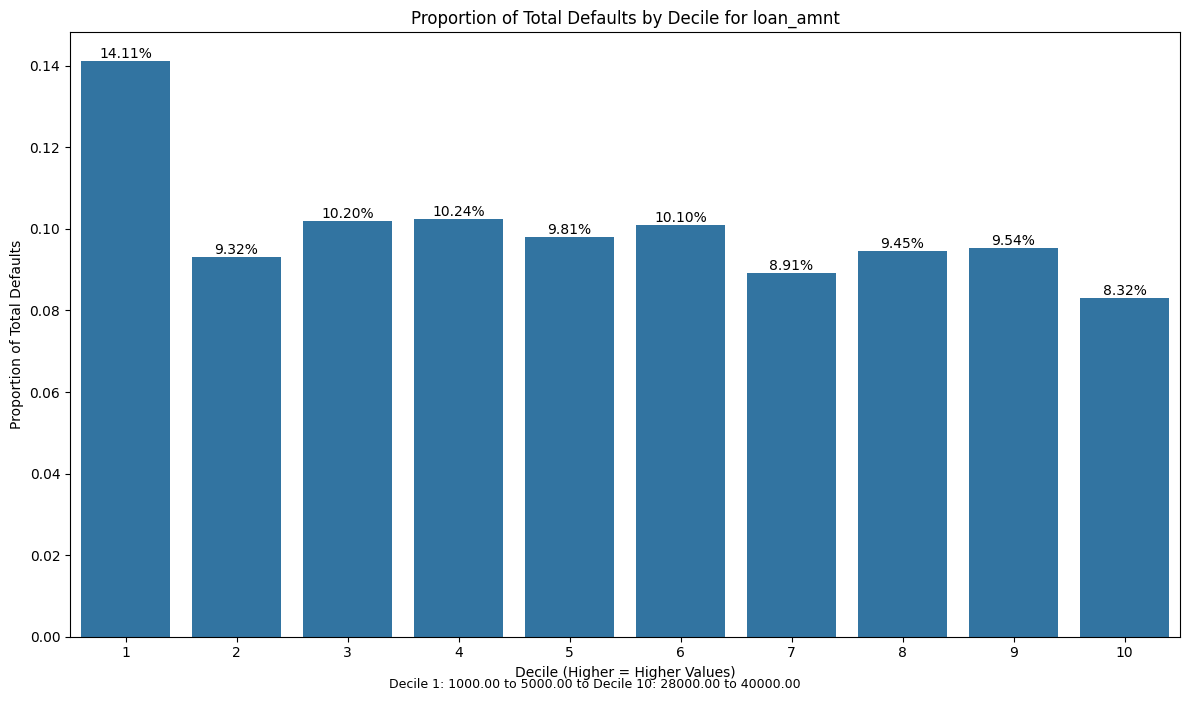


Analyzing annual_inc:
annual_inc: Correlation with loan_paid = 0.0527

Decile Statistics for annual_inc (10 bins created):
Decile 1: 1.00 to 33000.00 - Count: 21502, Number of Defaults: 9446, Default Rate: 43.93%, Proportion of Total Defaults: 9.00%
Decile 2: 33000.00 to 41000.00 - Count: 21134, Number of Defaults: 9694, Default Rate: 45.87%, Proportion of Total Defaults: 9.24%
Decile 3: 41000.00 to 49000.00 - Count: 20939, Number of Defaults: 9771, Default Rate: 46.66%, Proportion of Total Defaults: 9.31%
Decile 4: 49000.00 to 55000.00 - Count: 22088, Number of Defaults: 10455, Default Rate: 47.33%, Proportion of Total Defaults: 9.96%
Decile 5: 55000.00 to 62700.00 - Count: 19365, Number of Defaults: 9344, Default Rate: 48.25%, Proportion of Total Defaults: 8.90%
Decile 6: 62700.00 to 71000.00 - Count: 21154, Number of Defaults: 10563, Default Rate: 49.93%, Proportion of Total Defaults: 10.06%
Decile 7: 71000.00 to 81200.00 - Count: 20826, Number of Defaults: 10642, Default Rate: 51.

C:\Users\chris\AppData\Local\Temp\ipykernel_25224\96155333.py:25: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  decile_stats = df_decile.groupby('decile').agg(


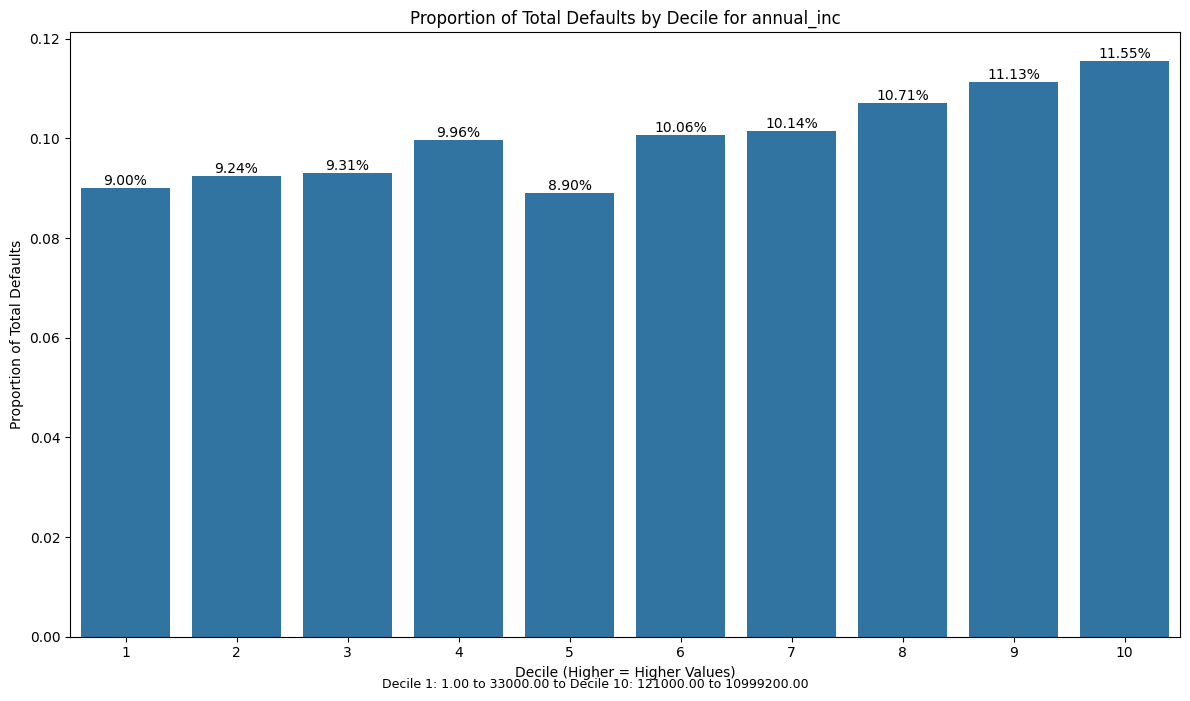


Analyzing dti:
dti: Correlation with loan_paid = -0.1061


C:\Users\chris\AppData\Local\Temp\ipykernel_25224\96155333.py:25: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  decile_stats = df_decile.groupby('decile').agg(



Decile Statistics for dti (10 bins created):
Decile 1: 0.00 to 7.71 - Count: 21040, Number of Defaults: 12471, Default Rate: 59.27%, Proportion of Total Defaults: 11.88%
Decile 2: 7.71 to 11.05 - Count: 20990, Number of Defaults: 12078, Default Rate: 57.54%, Proportion of Total Defaults: 11.51%
Decile 3: 11.05 to 13.69 - Count: 21023, Number of Defaults: 11763, Default Rate: 55.95%, Proportion of Total Defaults: 11.21%
Decile 4: 13.69 to 16.05 - Count: 20955, Number of Defaults: 11257, Default Rate: 53.72%, Proportion of Total Defaults: 10.72%
Decile 5: 16.05 to 18.41 - Count: 21081, Number of Defaults: 11012, Default Rate: 52.24%, Proportion of Total Defaults: 10.49%
Decile 6: 18.41 to 20.83 - Count: 20974, Number of Defaults: 10480, Default Rate: 49.97%, Proportion of Total Defaults: 9.98%
Decile 7: 20.83 to 23.47 - Count: 20947, Number of Defaults: 9913, Default Rate: 47.32%, Proportion of Total Defaults: 9.44%
Decile 8: 23.47 to 26.55 - Count: 21030, Number of Defaults: 9447, Defa

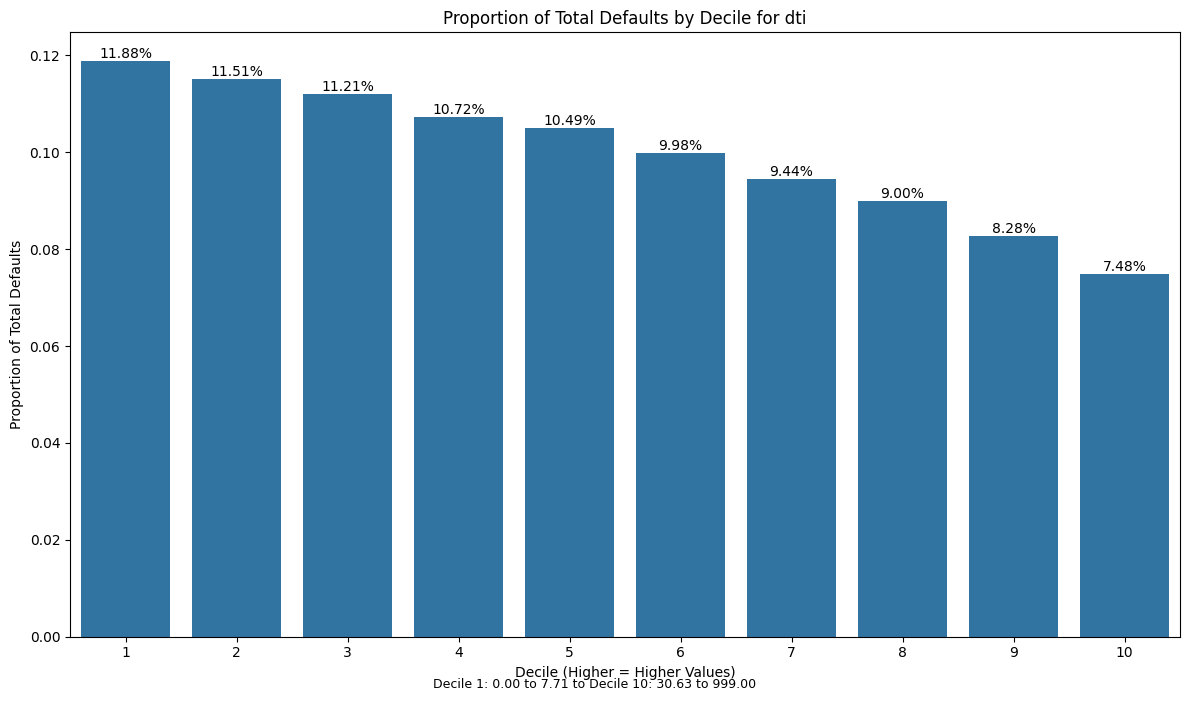


Analyzing total_acc:
total_acc: Correlation with loan_paid = 0.0163

Decile Statistics for total_acc (10 bins created):
Decile 1: 2.00 to 11.00 - Count: 23124, Number of Defaults: 11048, Default Rate: 47.78%, Proportion of Total Defaults: 10.53%
Decile 2: 11.00 to 15.00 - Count: 24976, Number of Defaults: 12136, Default Rate: 48.59%, Proportion of Total Defaults: 11.56%
Decile 3: 15.00 to 18.00 - Count: 22034, Number of Defaults: 10947, Default Rate: 49.68%, Proportion of Total Defaults: 10.43%
Decile 4: 18.00 to 20.00 - Count: 15158, Number of Defaults: 7476, Default Rate: 49.32%, Proportion of Total Defaults: 7.12%
Decile 5: 20.00 to 23.00 - Count: 22540, Number of Defaults: 11403, Default Rate: 50.59%, Proportion of Total Defaults: 10.86%
Decile 6: 23.00 to 26.00 - Count: 20471, Number of Defaults: 10280, Default Rate: 50.22%, Proportion of Total Defaults: 9.79%
Decile 7: 26.00 to 30.00 - Count: 23245, Number of Defaults: 11763, Default Rate: 50.60%, Proportion of Total Defaults: 1

C:\Users\chris\AppData\Local\Temp\ipykernel_25224\96155333.py:25: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  decile_stats = df_decile.groupby('decile').agg(


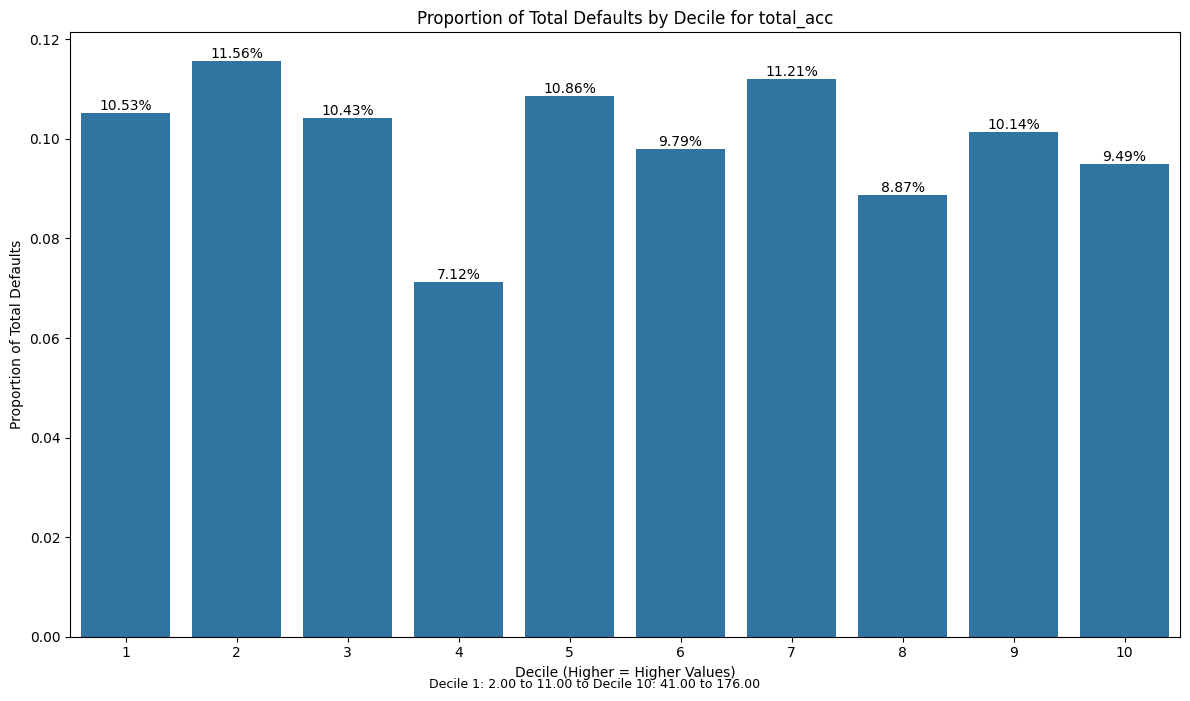


Analyzing total_bal_ex_mort:
total_bal_ex_mort: Correlation with loan_paid = 0.0032

Decile Statistics for total_bal_ex_mort (10 bins created):
Decile 1: 0.00 to 11405.00 - Count: 21003, Number of Defaults: 10979, Default Rate: 52.27%, Proportion of Total Defaults: 10.46%
Decile 2: 11405.00 to 18442.80 - Count: 20997, Number of Defaults: 10730, Default Rate: 51.10%, Proportion of Total Defaults: 10.22%
Decile 3: 18442.80 to 24847.70 - Count: 21000, Number of Defaults: 10392, Default Rate: 49.49%, Proportion of Total Defaults: 9.90%
Decile 4: 24847.70 to 31475.00 - Count: 21002, Number of Defaults: 10258, Default Rate: 48.84%, Proportion of Total Defaults: 9.77%
Decile 5: 31475.00 to 37467.00 - Count: 24443, Number of Defaults: 12624, Default Rate: 51.65%, Proportion of Total Defaults: 12.03%
Decile 6: 37467.00 to 44260.00 - Count: 17558, Number of Defaults: 8642, Default Rate: 49.22%, Proportion of Total Defaults: 8.23%
Decile 7: 44260.00 to 54568.00 - Count: 20998, Number of Defaults

C:\Users\chris\AppData\Local\Temp\ipykernel_25224\96155333.py:25: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  decile_stats = df_decile.groupby('decile').agg(


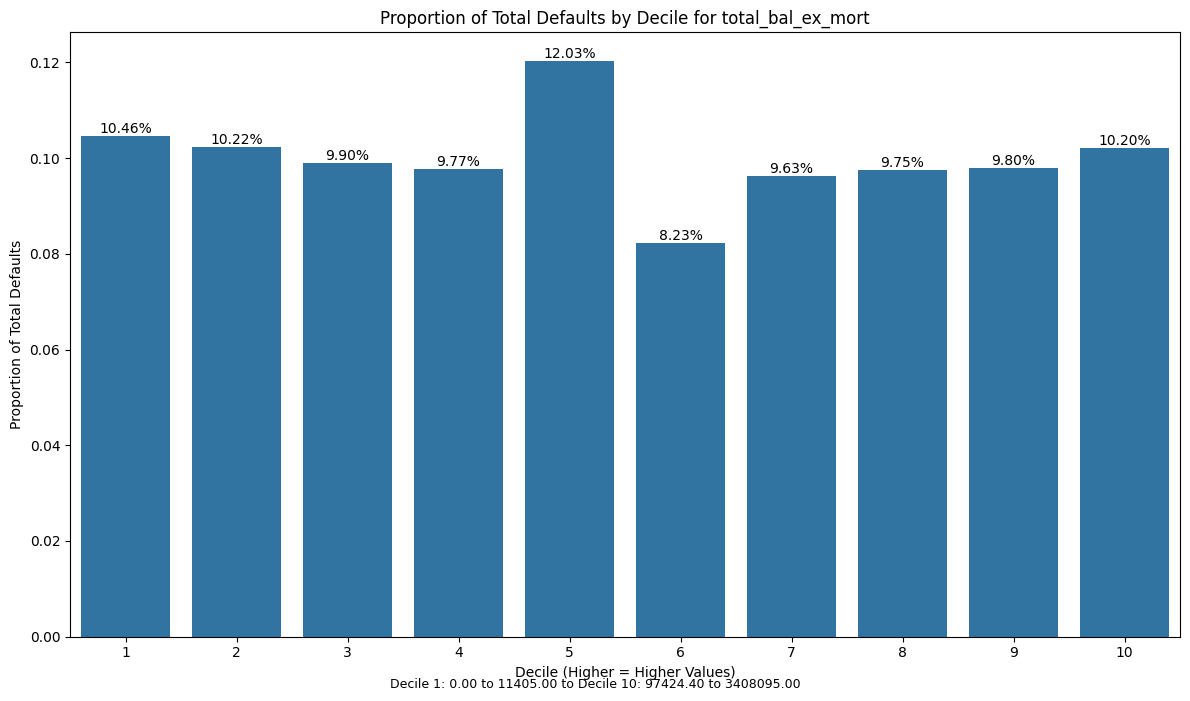


Analyzing total_bc_limit:
total_bc_limit: Correlation with loan_paid = 0.0940

Decile Statistics for total_bc_limit (10 bins created):
Decile 1: 0.00 to 3800.00 - Count: 21481, Number of Defaults: 9380, Default Rate: 43.67%, Proportion of Total Defaults: 8.94%
Decile 2: 3800.00 to 6300.00 - Count: 20542, Number of Defaults: 9314, Default Rate: 45.34%, Proportion of Total Defaults: 8.87%
Decile 3: 6300.00 to 8800.00 - Count: 21008, Number of Defaults: 9672, Default Rate: 46.04%, Proportion of Total Defaults: 9.21%
Decile 4: 8800.00 to 11500.00 - Count: 21018, Number of Defaults: 9852, Default Rate: 46.87%, Proportion of Total Defaults: 9.39%
Decile 5: 11500.00 to 14300.00 - Count: 24902, Number of Defaults: 12604, Default Rate: 50.61%, Proportion of Total Defaults: 12.01%
Decile 6: 14300.00 to 17500.00 - Count: 17364, Number of Defaults: 8482, Default Rate: 48.85%, Proportion of Total Defaults: 8.08%
Decile 7: 17500.00 to 22500.00 - Count: 20898, Number of Defaults: 10374, Default Rate

C:\Users\chris\AppData\Local\Temp\ipykernel_25224\96155333.py:25: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  decile_stats = df_decile.groupby('decile').agg(


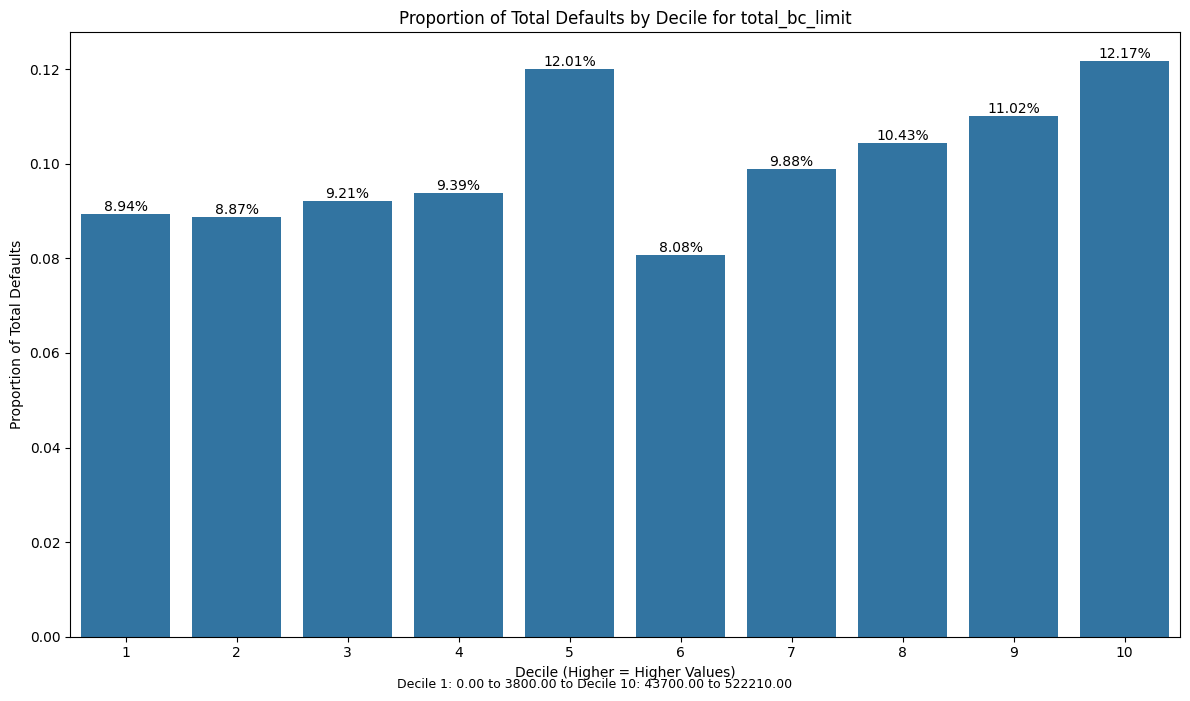


Analyzing total_il_high_credit_limit:
total_il_high_credit_limit: Correlation with loan_paid = -0.0008
Could not analyze total_il_high_credit_limit by deciles: Bin labels must be one fewer than the number of bin edges

Analyzing tot_hi_cred_lim:
tot_hi_cred_lim: Correlation with loan_paid = 0.0985

Decile Statistics for tot_hi_cred_lim (10 bins created):
Decile 1: 0.00 to 27575.00 - Count: 21001, Number of Defaults: 9559, Default Rate: 45.52%, Proportion of Total Defaults: 9.11%
Decile 2: 27575.00 to 41899.80 - Count: 20999, Number of Defaults: 9299, Default Rate: 44.28%, Proportion of Total Defaults: 8.86%
Decile 3: 41899.80 to 57050.00 - Count: 21001, Number of Defaults: 9446, Default Rate: 44.98%, Proportion of Total Defaults: 9.00%
Decile 4: 57050.00 to 77583.60 - Count: 20999, Number of Defaults: 9373, Default Rate: 44.64%, Proportion of Total Defaults: 8.93%
Decile 5: 77583.60 to 101481.00 - Count: 25980, Number of Defaults: 13119, Default Rate: 50.50%, Proportion of Total Defau

C:\Users\chris\AppData\Local\Temp\ipykernel_25224\96155333.py:25: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  decile_stats = df_decile.groupby('decile').agg(


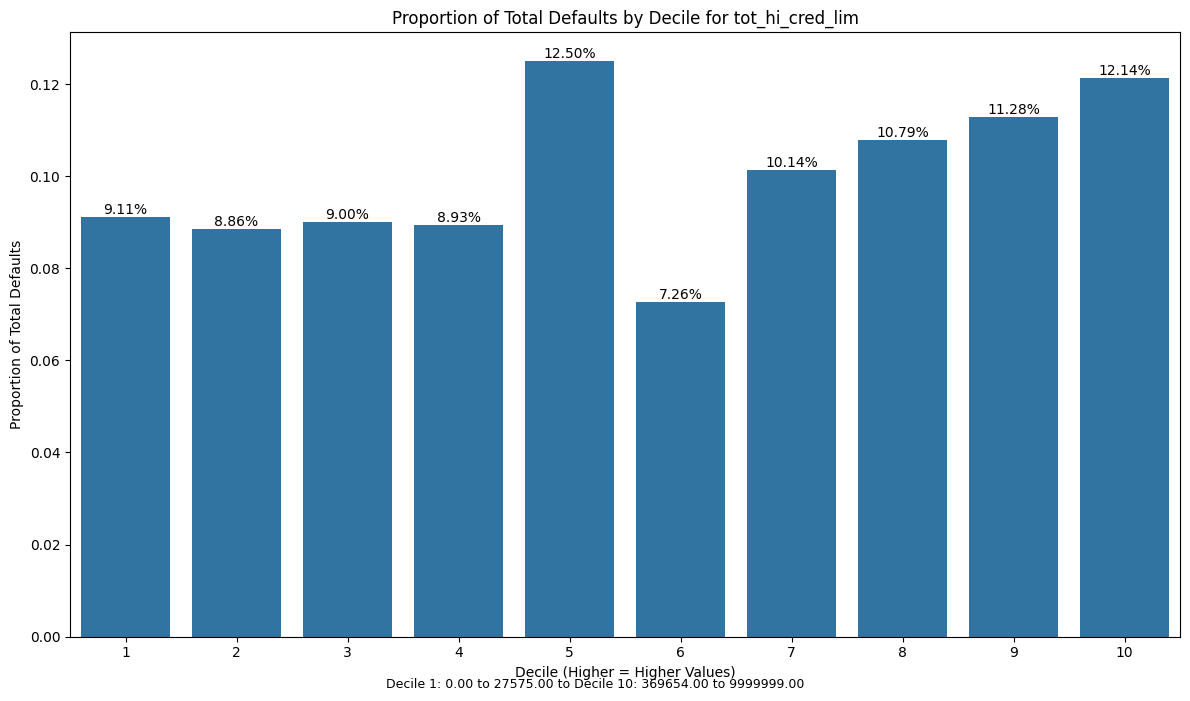


Analyzing revol_util:
revol_util: Correlation with loan_paid = -0.0789

Decile Statistics for revol_util (10 bins created):
Decile 1: 0.00 to 19.80 - Count: 21155, Number of Defaults: 12543, Default Rate: 59.29%, Proportion of Total Defaults: 11.95%
Decile 2: 19.80 to 30.80 - Count: 21017, Number of Defaults: 11540, Default Rate: 54.91%, Proportion of Total Defaults: 10.99%
Decile 3: 30.80 to 39.10 - Count: 21035, Number of Defaults: 10929, Default Rate: 51.96%, Proportion of Total Defaults: 10.41%
Decile 4: 39.10 to 46.60 - Count: 20822, Number of Defaults: 10384, Default Rate: 49.87%, Proportion of Total Defaults: 9.89%
Decile 5: 46.60 to 53.70 - Count: 21247, Number of Defaults: 10542, Default Rate: 49.62%, Proportion of Total Defaults: 10.04%
Decile 6: 53.70 to 60.60 - Count: 20876, Number of Defaults: 9966, Default Rate: 47.74%, Proportion of Total Defaults: 9.49%
Decile 7: 60.60 to 67.90 - Count: 21103, Number of Defaults: 10015, Default Rate: 47.46%, Proportion of Total Default

C:\Users\chris\AppData\Local\Temp\ipykernel_25224\96155333.py:25: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  decile_stats = df_decile.groupby('decile').agg(


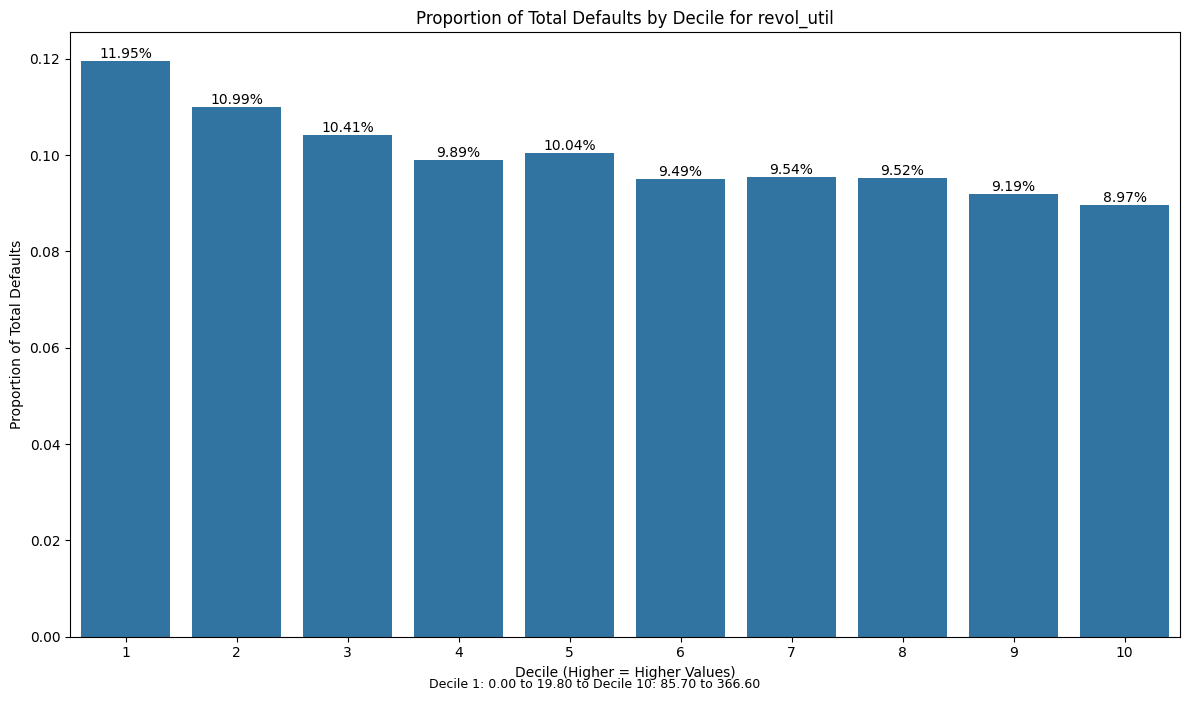


Analyzing credit_age_years:
credit_age_years: Correlation with loan_paid = 0.0549

Decile Statistics for credit_age_years (10 bins created):
Decile 1: 9.71 to 17.71 - Count: 21103, Number of Defaults: 9403, Default Rate: 44.56%, Proportion of Total Defaults: 8.96%
Decile 2: 17.71 to 19.79 - Count: 21541, Number of Defaults: 9908, Default Rate: 46.00%, Proportion of Total Defaults: 9.44%
Decile 3: 19.79 to 21.46 - Count: 21647, Number of Defaults: 10110, Default Rate: 46.70%, Proportion of Total Defaults: 9.63%
Decile 4: 21.46 to 22.96 - Count: 20395, Number of Defaults: 9949, Default Rate: 48.78%, Proportion of Total Defaults: 9.48%
Decile 5: 22.96 to 24.46 - Count: 20776, Number of Defaults: 10477, Default Rate: 50.43%, Proportion of Total Defaults: 9.98%
Decile 6: 24.46 to 26.12 - Count: 20875, Number of Defaults: 10726, Default Rate: 51.38%, Proportion of Total Defaults: 10.22%
Decile 7: 26.12 to 28.38 - Count: 20958, Number of Defaults: 10850, Default Rate: 51.77%, Proportion of T

C:\Users\chris\AppData\Local\Temp\ipykernel_25224\96155333.py:25: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  decile_stats = df_decile.groupby('decile').agg(


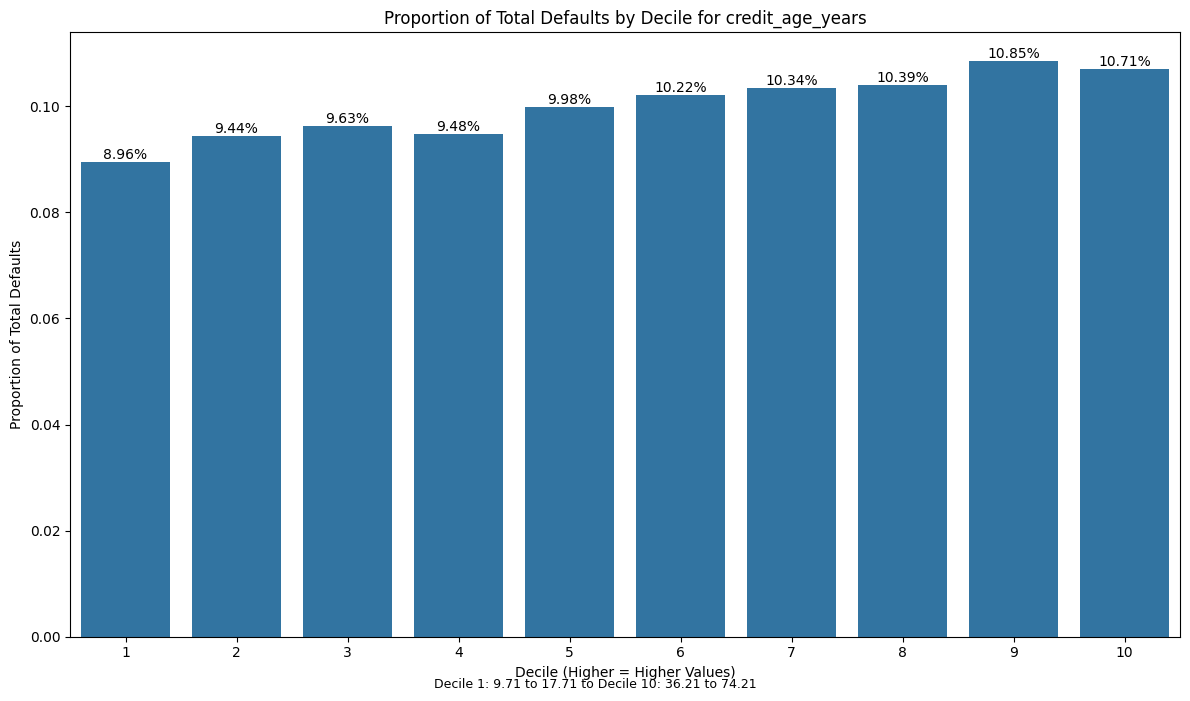

In [38]:
# ANALYZING THE CONTINOUS VARS!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!
# proportion_of_defaults: This shows what percentage of all defaults across the entire dataset occur in each decile. It answers "Where are the defaults concentrated?"
# default_rate: This would show the percentage of observations within each decile that defaulted. It answers "How risky is this decile?"
def analyze_by_deciles(df, var, target):
    # Create deciles
    df_decile = df[[var, target]].copy()
    
    try:
        # First create the bins without labels to see how many we get
        temp_decile = pd.qcut(df[var], 10, duplicates='drop')
        num_bins = temp_decile.cat.categories.size
        
        # Now create the deciles with the correct number of labels
        df_decile['decile'] = pd.qcut(df[var], num_bins, labels=range(1, num_bins+1), duplicates='drop')
        
        # Get the bin edges to understand what each decile represents
        bin_edges = pd.qcut(df[var], num_bins, duplicates='drop', retbins=True)[1]
        
        # Create range labels for each decile
        range_labels = []
        for i in range(len(bin_edges)-1):
            range_labels.append(f"{bin_edges[i]:.2f} to {bin_edges[i+1]:.2f}")
        
        # Calculate statistics by decile
        decile_stats = df_decile.groupby('decile').agg(
            count=pd.NamedAgg(column=target, aggfunc='count'),
            num_defaults=pd.NamedAgg(column=target, aggfunc='sum')
        )
        
        # Calculate proportion of total defaults
        total_defaults = decile_stats['num_defaults'].sum()
        decile_stats['proportion_of_defaults'] = decile_stats['num_defaults'] / total_defaults
        decile_stats['default_rate'] = decile_stats['num_defaults'] / decile_stats['count']

        # Add the range information to the statistics
        decile_stats['range'] = range_labels
        
        # Print decile information
        print(f"\nDecile Statistics for {var} ({num_bins} bins created):")
        for i, row in decile_stats.iterrows():
            print(f"Decile {i}: {row['range']} - Count: {row['count']}, "
                    f"Number of Defaults: {row['num_defaults']}, "
                    f"Default Rate: {row['default_rate']:.2%}, "
                    f"Proportion of Total Defaults: {row['proportion_of_defaults']:.2%}")
        
        # Plot
        plt.figure(figsize=(12, 7))
        ax = sns.barplot(x=decile_stats.index.astype(str), y='proportion_of_defaults', data=decile_stats)
        plt.title(f"Proportion of Total Defaults by Decile for {var}")
        plt.xlabel("Decile (Higher = Higher Values)")
        plt.ylabel("Proportion of Total Defaults")
        
        # Add labels to the bars
        for i, p in enumerate(ax.patches):
            ax.annotate(f"{decile_stats['proportion_of_defaults'].iloc[i]:.2%}", 
                       (p.get_x() + p.get_width() / 2., p.get_height()), 
                       ha='center', va='bottom')
        
        # Add a note about the decile ordering
        plt.figtext(0.5, 0.01, f"Decile 1: {range_labels[0]} to Decile {num_bins}: {range_labels[-1]}", 
                   ha='center', fontsize=9)
        
        plt.tight_layout()
        plt.show()
        
        return decile_stats
        
    except Exception as e:
        print(f"Could not analyze {var} by deciles: {str(e)}")
        return None

# Process each continuous variable
for var in continuous_vars:
    print(f"\nAnalyzing {var}:")
    
    # Calculate correlation with target
    corr = analyze_correlation(df, var, target_var)
    analysis_results['correlation'][var] = corr
    
    
    # Analyze by deciles
    decile_stats = analyze_by_deciles(df, var, target_var)
    analysis_results['decile_stats'][var] = decile_stats